# 06 · Java 的运行原理


来源：[飞书讲义《第6章：Java的运行原理》](https://heuqqdmbyk.feishu.cn/docx/MDkkdWjlqoP6MHxCCbwcMZhcnbf) · 整理日期：2026-09-26。

按讲义原顺序保留全部文字、5 段代码和 14 张内存示意图。必要的“勘误”和“补充”在对应内容旁单独标明。图中的地址、栈帧和内存布局是帮助理解的示意，不代表某次运行中 JVM 的真实物理地址；代码是独立示例或语法片段，`sout` 需要替换为 `System.out.println` 才能编译。


> 大家学习中如果碰到任何的困难(BUG、学习规划、学习资料等)，都可以加入<a href="https://heuqqdmbyk.feishu.cn/docx/ZZ4MdTFkaou4m7x4bVLcpOc7nRf"><strong>黑马智学伴侣</strong></a><a href="https://heuqqdmbyk.feishu.cn/docx/ZZ4MdTFkaou4m7x4bVLcpOc7nRf"><strong>(有问题点我)</strong></a>寻求帮助，有学习交流群，老师、同学在线答疑。还有独享的企业级项目，避免与人撞车。


## Java的运行机制

### 目前的运行机制

在之前，我们熟悉的运行机制只有两步：

- 写代码
- 运行看结果

但是，Java真正的运行机制并没有这么简单，因为Java代码是给人看的，并不是给机器看的，机器根本不认识Java语言。

那Java是如何操作，才能让操作系统看懂并且能运行出我们想要的结果呢？今天我们就学习一下。

### Java的运行机制

<strong>Java的运行机制如下：</strong>

1. 编写Java代码，产生后缀名为<code>.java</code>的文件。
2. 编译java文件，产生后缀名为<code>.</code>class的文件。
3. 在虚拟机中运行class文件，看到程序运行的结果。

<strong>详细解释：</strong>

<strong>java文件：</strong>源文件，是程序员编写的，也是给程序员看的。计算机只能识别01，无法识别java文件中的内容，此时就需要翻译一下。

<strong>编译：</strong>编译的其实就是翻译，把机器看不懂的内容翻译成可以看懂的内容，并产生新的class文件，也叫做字节码文件。

<strong>class文件：</strong>不是给人看的，是给机器看的，所以如果我们强行用记事本打开该文件发现是一堆乱码。

> **补充：**`.class` 文件保存的是 JVM 字节码和相关元数据，不是某种操作系统的 CPU 机器码。JVM 可以解释字节码，也可以在运行时用 JIT 编译成当前处理器的机器码；因此同一个 `.class` 通常可由不同系统上的 JVM 执行。

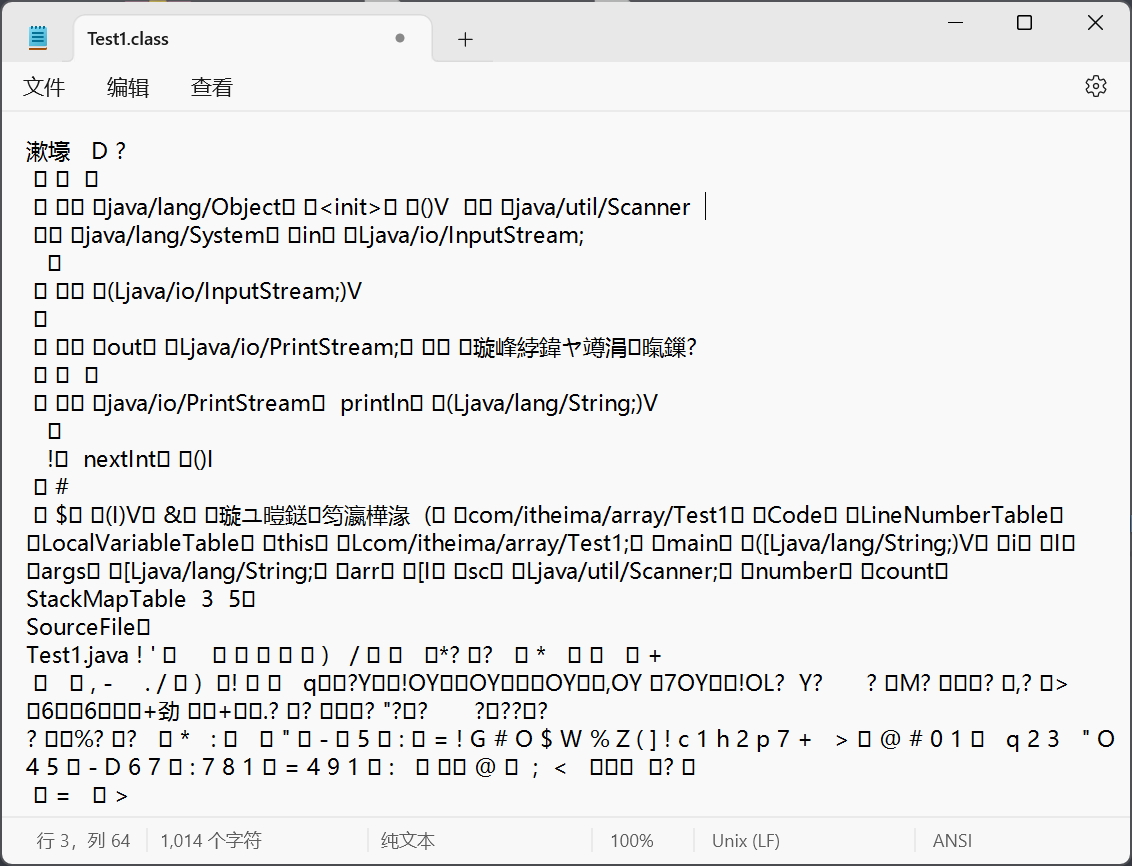

<strong>运行：</strong>真正运行的，就是翻译之后的class文件。但是class文件并不是直接运行在操作系统里面的，而是运行在虚拟里面的，那什么是虚拟机呢？

### 虚拟机

虚拟机简单理解，就是一个虚拟机的操作系统。

> **勘误：**这是帮助初学者理解的比喻。JVM 不是一个完整的操作系统，而是运行 Java 字节码的运行时环境，负责类加载、内存管理、执行和部分平台适配。

<strong>举例：</strong>

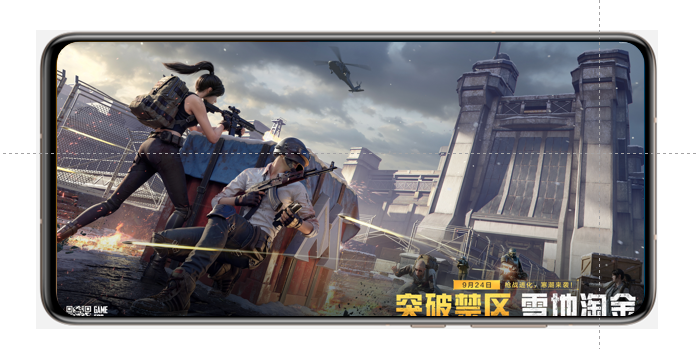

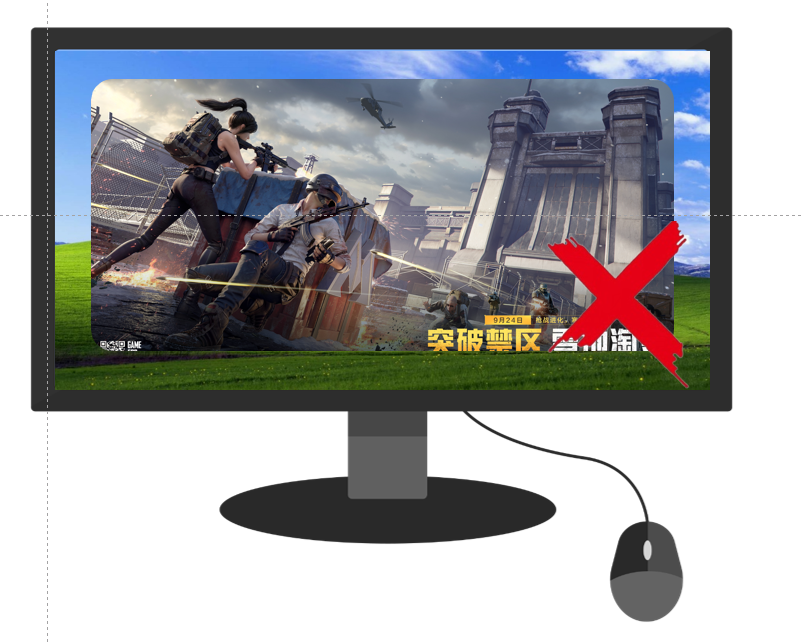

如果，我们要把手机上的游戏在windows电脑中运行，是不行的，因为Windows无法识别。

<strong>那我们该如何操作呢？</strong>

此时就可以在Windows操作系统中安装一个安卓手机模拟器，这样，在这部虚拟的手机中，就可以玩手机游戏了。这部虚拟出来的手机，就可以理解为虚拟机。

<strong>带来的好处：</strong>

只要下载不同版本的虚拟机。那么这款手机游戏，就可以在任意的操作系统中运行。

这种可以在任意操作系统都能运行的特性，有一个专业名词，叫做跨平台

> <strong>总结：</strong>
> 
> 不需要修改源代码，就可以在任意操作系统中运行的特性，就叫做跨平台。
> 
> <strong>好处：</strong>
> 
> 降低开发成本，不需要针对不同的操作系统开发多个版本了，一个安装包，可以在任意操作系统中运行。

<strong>注意：</strong>

手机游戏，原本不是跨平台的，他只能在手机中运行，是借助了不同版本的虚拟机，实现的跨平台

<strong>Java的虚拟机：</strong>

Java运行规则，跟刚刚的手机游戏，是一模一样的，他并不是直接运行在操作系统中的，而是运行在Java的虚拟机中的，Java的虚拟机英文名称（Java Virtual Machine），简称：JVM。

我们只要针对于不同的操作系统，安装不同的虚拟机，这样，Java就可以实现跨平台，一套代码，就可以在任意的操作系统中运行。

<strong>虚拟机安装：</strong>

Java的虚拟机JVM不需要单独安装，第一章节安装的JDK当中，已经包含JVM。所以，针对于不同的操作系统，安装不同的JDK就可以了。

### 运行机制总结

1. 编写Java代码，产生后缀名为<code>.java</code>的文件。
2. 编译java文件，产生后缀名为<code>.</code>class的文件。
3. 在虚拟机中运行class文件，看到程序运行的结果。


## 内存和内存地址

知道了Java完整的运行过程，我们知道Java程序最终是运行在虚拟机里面的，那么在虚拟机里面，又是怎么运行的呢？接下来，我们就花一点时间去研究一下。

在研究之前，我们要先知道两个知识点：

- 内存
- 内存地址

### 内存

<strong>内存：</strong>也叫做随机访问存储（Random Access Memory，简称RAM）是计算机中的一种主要存储设备。它可以快速读取和写入数据。

<strong>作用：</strong>软件在运行的时候，用来临时存储数据的。

<strong>举例1：</strong>

在记事本中输入任意一段文字，没有保存此时数据就是在内存中临时存储。

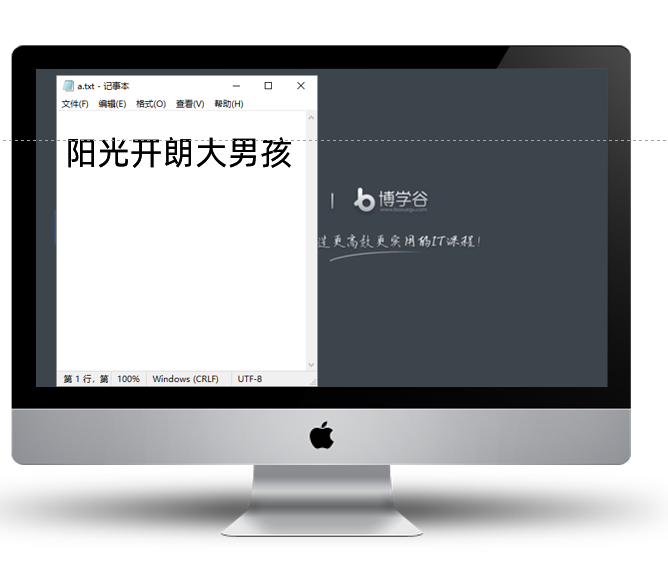

<strong>特点：</strong>

因为是临时存储，文件一旦关闭，数据就会丢失。

<strong>举例2：</strong>

计算器，也是一样的当哥们点击了2+7的时候，计算器也会把2和7，临时存储到内存当中。当我们点击等于，要进行计算了，计算器就会到内存中找到2和7这个两个数据交给CPU进行计算。

所以，内存就是软件在运行的时候，用来临时存储数据的。

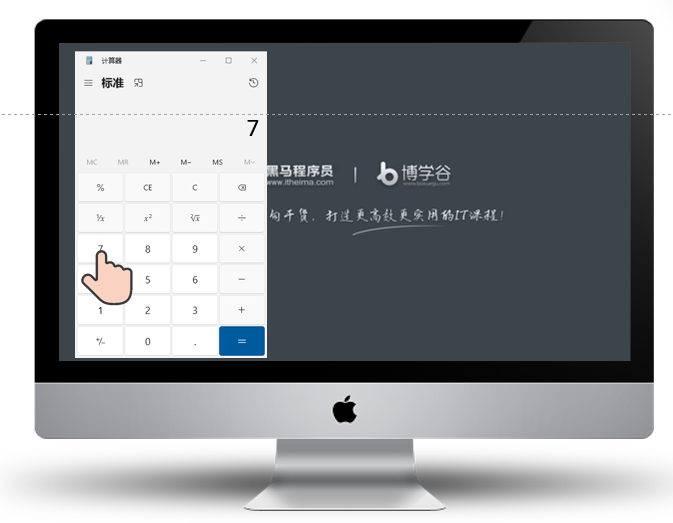

### 内存地址

#### 介绍

现在的内存非常大，基本都是16G，32G，64G，这么大的空间如果直接把数据放在一个任意的地方，后续在找的时候是非常麻烦的，所以为了更好的管理内存，操作系统，会把内存以字节为单元，划分为很多小空间。一个小空间就是一个字节，也就是8个bit位。

> **补充：**这是操作系统内存管理的入门模型。现代系统通常使用虚拟内存和分页，Java 程序看到的是 JVM 管理的对象、栈帧和引用，不能据此推断每个 Java 变量一定对应一个连续的物理内存字节。

为了方便管理这些小空间，操作系统还给每一个小空间加了一个独立的编号，而这里的编号就是内存地址。

#### 规则

<strong>32位的操作系统：</strong>

内存地址以32位的二进制表示，其实就是32位的01，表现形式如下：

<code>0000 0001 0100 0000 0100 0000 0010 0001 </code>

<strong>内存地址范围：</strong>

- 最小地址：<code>0000 0000 0000 0000 0000 0000 0000 0000 </code>
- 最大地址：<code>1111 1111 1111 1111 1111 1111 1111 1111 </code>

<strong>最大支持内存：</strong>

因为，一个内存地址表示一个字节，32位的操作系统最多有2 ^ 32次方个内存地址。

所以，32位的操作系统最大能支持的内存为：2^ 32 &#42; 1字节

计算结果为：42,9496,7296（字节）

> **勘误：**`2^32` 字节是 `4,294,967,296` 字节，约为 `4 GiB`（常口语化称 4 GB），讲义中的数字分组写错了。这里是理论地址空间上限，实际可用内存还要受系统和硬件限制。

换算成熟悉的单位：<strong>4（GB）</strong>

这也是32位操作系统逐渐被淘汰的主要原因

<strong>64位的操作系统：</strong>

内存地址以32位的二进制表示，其实就是64位的01，表现形式如下：

> **勘误：**这里前半句“以 32 位表示”是笔误，64 位操作系统的地址宽度应按 64 位理解。实际可用虚拟地址空间还会受硬件、操作系统和配置限制，不一定真的能使用全部 `2^64` 个地址。

<code>00000001 01000000 01000000 00100001 00000001 01000000 01000000 00100001 </code>

<strong>内存地址范围：</strong>

- 最小地址：<code>64个0  00000000 00000000 ... 00000000 00000000 </code>
- 最大地址：<code>64个1  11111111 11111111 ... 11111111 11111111 </code>

<strong>最大支持内存：</strong>

因为，一个内存地址表示一个字节，64位的操作系统最多有2 ^ 64次方个内存地址。

所以，64位的操作系统最大能支持的内存为：2^ 64 &#42; 1字节

计算结果为：1844,6744,0737,0955,1616（字节）

换算成熟悉的单位：17,592,186<strong>（GB） </strong>17,179<strong>（GB） </strong>

> **勘误：**`2^64` 字节约为 `16 EiB`，换算为二进制单位是 `17,179,869,184 GiB`；讲义中的 `17,592,186 GB` 和 `17,179 GB` 都少了数量级。它同样只是理论地址空间上限。

目前而言是足够使用了

<strong>表现形式：</strong>

在计算机中内存地址是以二进制的形式表示的，但是太长了，不方便阅读，所以我们会转成十六进制，这样阅读起来短一点。

<strong>举例：</strong>

计算机实际的内存地址：

<code>00000000 00000000 00000000 00000000 01101100 11011110 01010101 00100010 </code>

转成十六进制：

<code>0x</code><code>6CDE5522 </code>

> <strong>备注1：</strong>十六进制就是逢十六进一，每一位由0123456789abcdef组成
> 
> a为10，b为11，c为12，d为13，e为14，f为15
> 
> <strong>备注2：</strong>不同的进行在书写的时候为了避免混淆，都有前缀
> 
> - 二进制前缀0b，写作0b110，表示110是二进制的
> - 八进制前缀0，写作0110，表示110是八进制的
> - 十进制无前缀，写作110，表示110是十进制的
> - 十六进制前缀0x，写作0x110，表示110是十六进制的


## Java中的内存分配

Java为了更好的管理内存，把内存分为了五个模块：

- 栈内存
- 堆内存
- 方法区
- 本地方法栈
- 程序计数器

<strong>栈内存：</strong>

每个线程都有自己独立的栈，目前只要考虑一个即可，方法被调用进栈执行，执行完毕出栈。

简单理解：栈跟方法有关。

<strong>堆内存：</strong>

所有线程共享，存储对象、数组、字符串常量池。

> **补充：**初学阶段可把对象和数组理解为位于堆中；字符串对象通常也在堆中，但“运行时常量池”属于方法区的逻辑组成，具体实现和版本会有差异。

简单理解：堆跟new关键字有关，只要通过new关键字开辟的小空间都是开在堆内存中的。

<strong>方法区：</strong>

JDK7永久代实现，JDK8+元空间实现，从虚拟机内部移到本地内存。存储字节码信息、常量、静态变量。

> **补充：**“方法区”是 JVM 规范中的逻辑区域，具体实现会因 JVM 而异。HotSpot 在 JDK 7 及以前常用永久代，JDK 8 起改为元空间；元空间主要使用本地内存。不要把规范中的方法区、HotSpot 的元空间和操作系统物理内存简单当成同一个概念。

简单理解：方法区是存储class字节码文件的。当运行一个类的时候，会把这个类的字节码文件加载到内存中临时存储。

<strong>本地方法栈：</strong>

调用本地Native方法。暂时用不上，不需要记忆。

<strong>程序计数器：</strong>

每个线程独立、记录当前线程执行的字节码指令地址（行号）。暂时用不上，不需要记忆。

<strong>小结：</strong>

需要我们目前记忆的内容如下：

- 栈内存：就是方法运行时使用的内存。咱哥们平时，经常写的，程序的主入口main，也是一个方法，只不过这个方法不是我们自己调用的，而是在程序启动的时候，由虚拟机自动调用的，一旦调用，main方法就会进栈执行。当main方法里面，所有的代码执行完毕，main方法就会从栈里面出去，所有的方法都遵守这样的规则。
- 堆内存：是跟new关键字有关的。new关键字的作用，就是在堆内存中开辟一个新的空间。要注意，堆内存中的空间，是带有地址值的。
- 方法区：是用来记录字节码信息的，其实就是存那个class文件。程序在运行的时候，会把相关类的字节码文件加载到方法区当中临时存储。

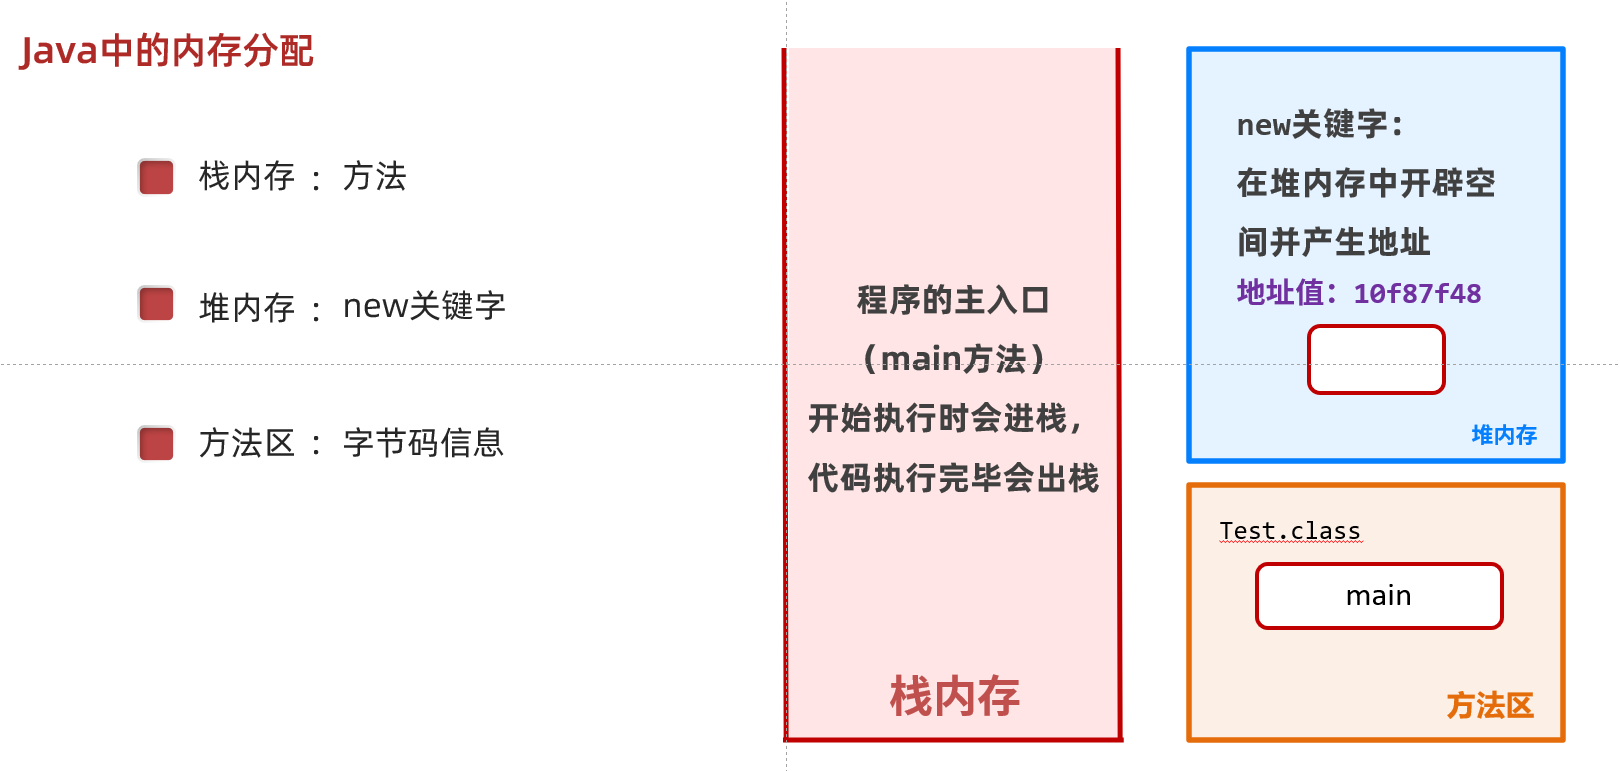


## 变量在内存中的情况

接下来，我们学习变量在内存中的情况，代码如下：

````java
public class Memory {
    public static void main(String[] args) {
        int a = 10;
        int b = 20;
        int c = a + b;
        System.out.println(c);
    }
 }
````

<strong>完整流程如下：</strong>

1. 把相关类的字节码文件，加载到方法区。此时<code>Memory.class</code>就在内存中了
2. 虚拟机自动调用main方法，main方法，被加载进栈，准备从上往下依次执行代码。
3. 第一行代码，在main方法里面定义了一个变量<code>int  a = 10</code>，在main当中开辟了一个小空间，名字叫做a，里面存着10。
4. 同理 int b 等于20，就是把刚刚的动作又重复了一下，又出现了第二个小空间，名字叫做b，里面存着20。
5. 第三行，<code>int c = a + b</code>，同样的，也是在main里面开辟了一个小空间，名字叫做c。
6. 找a和b里面记录的值，相加得到结果30，赋值给c。

内存图解如下：

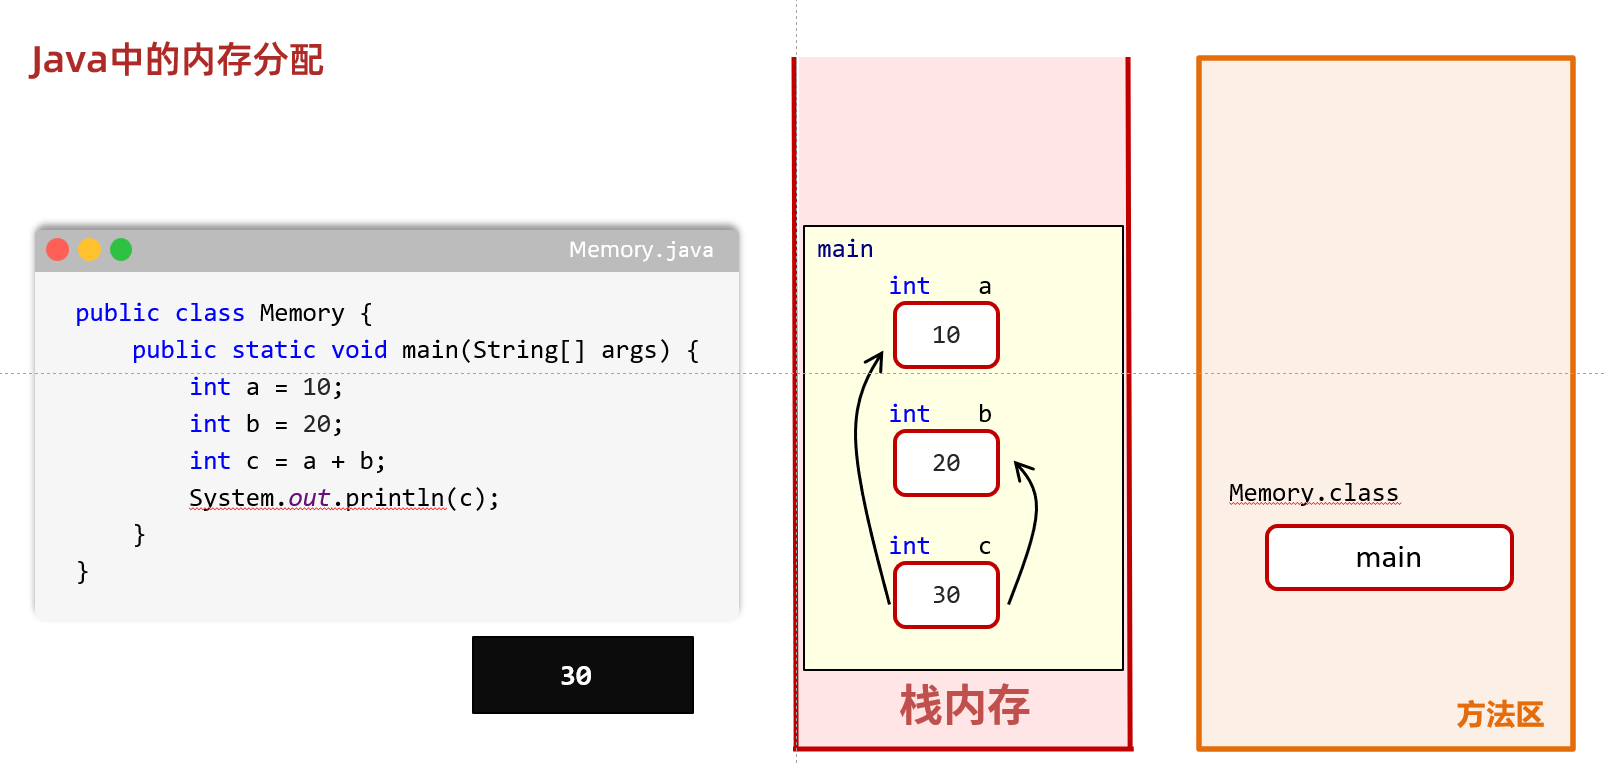


## 基本类型的变量在方法中进行传递

代码如下：

````java
public class Memory {
    public static void main(String[] args) {
       int a = 10;
        int b = 20;
        sout("交换前:" + a + ", " + b);
        change(a, b);
        sout("交换后:" + a + ", " + b);
    }

    public static void change(int a, int b) {
        int temp = a;
        a = b;
        b = temp;
    }
}
````

> **勘误：**`sout` 是 IDEA 的输出模板缩写，不是 Java 语法。运行前应替换为 `System.out.println("交换前:" + a + ", " + b);` 以及对应的“交换后”打印语句。

<strong>完整流程如下：</strong>

1. 把相关类的字节码文件，加载到方法区。此时<code>Memory.class</code>就在内存中了
2. 虚拟机自动调用main方法，main方法，被加载进栈，准备从上往下依次执行代码。
3. 定义变量a，定义变量b，在main方法当中，就有了两个小空间，分别叫做a和b，存储数据10和20
4. 调用change方法，方法被调用，进栈执行。chang里面有两个形参a和b，记录的是传递过来的10和20。

内存图解如下：

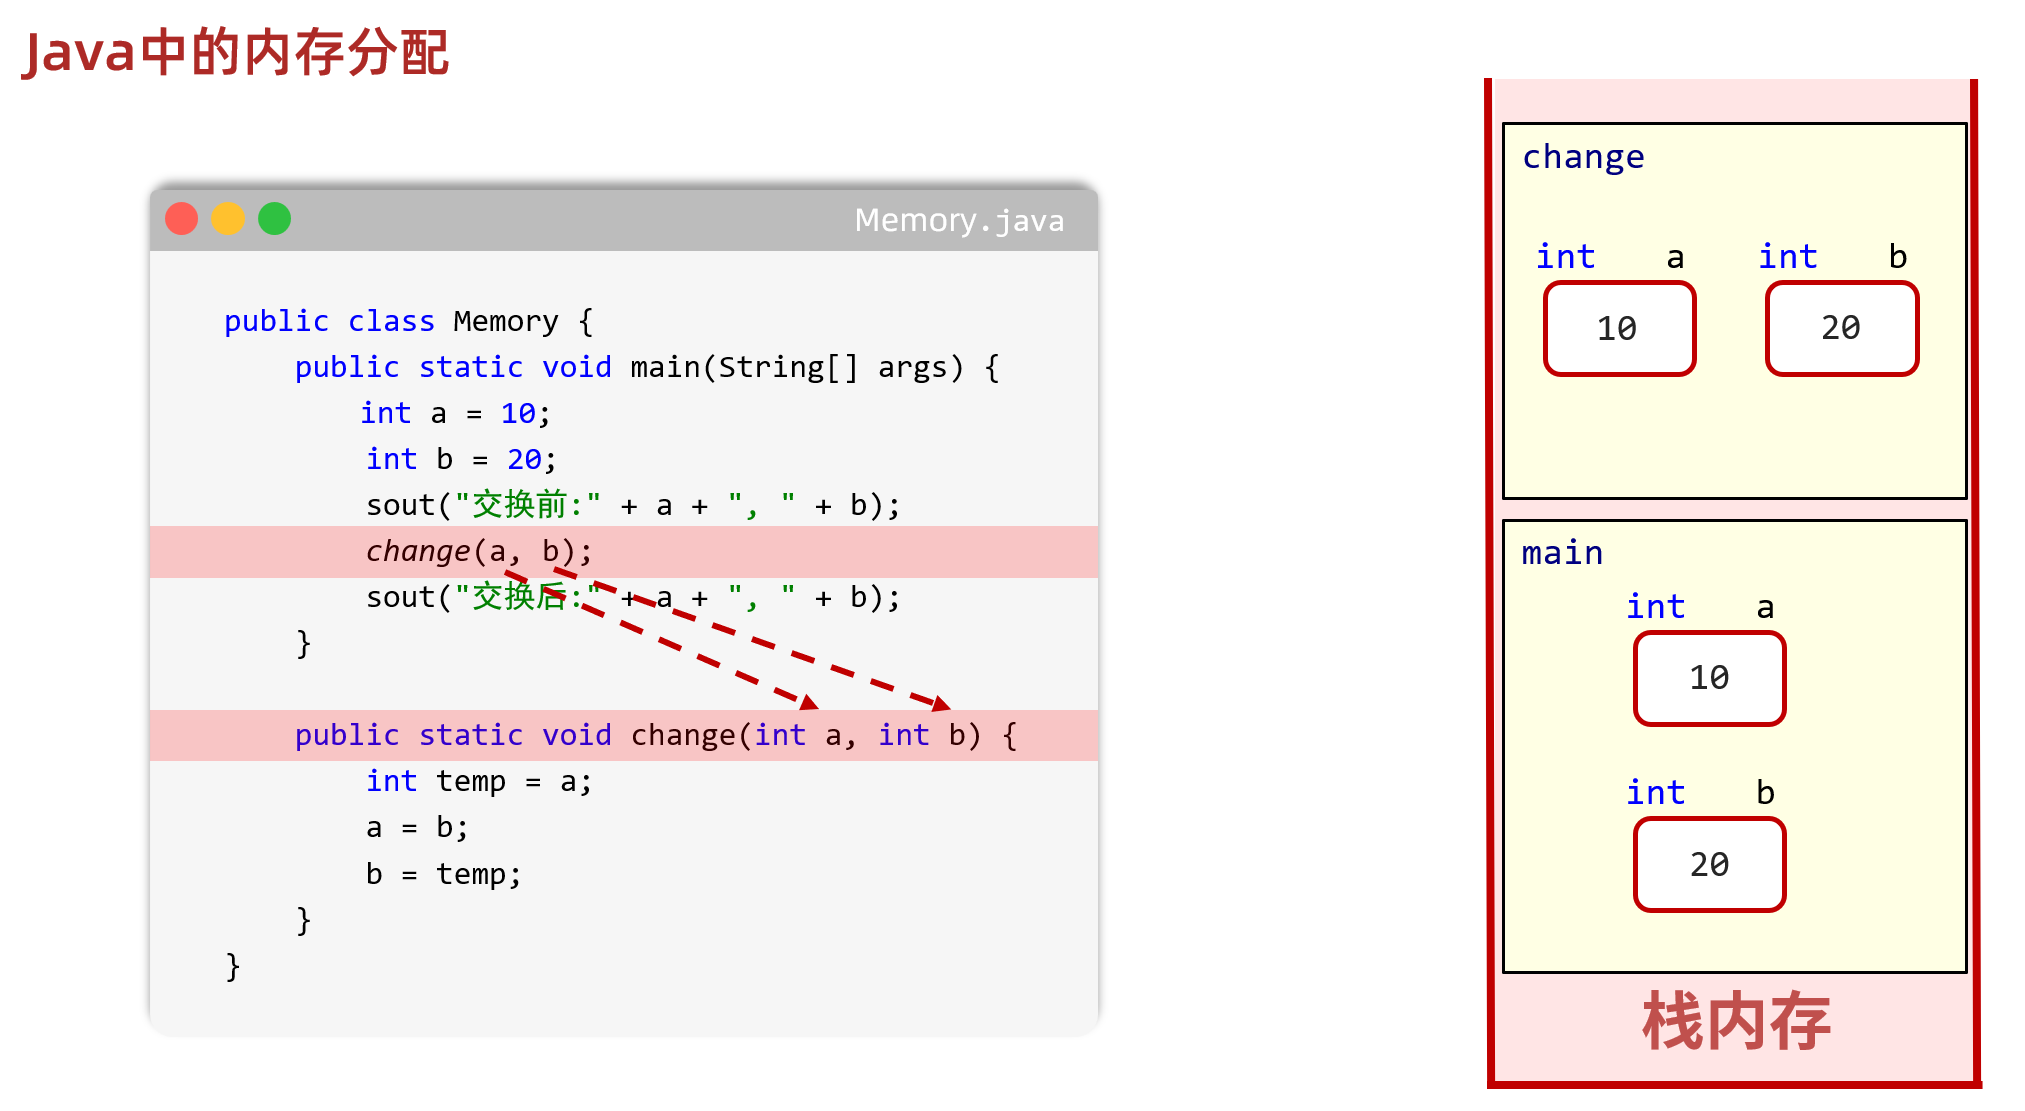

1. change方法里面，进行了数据的交换，注意，此时交换的是change方法里面的a和b

内存图解如下：

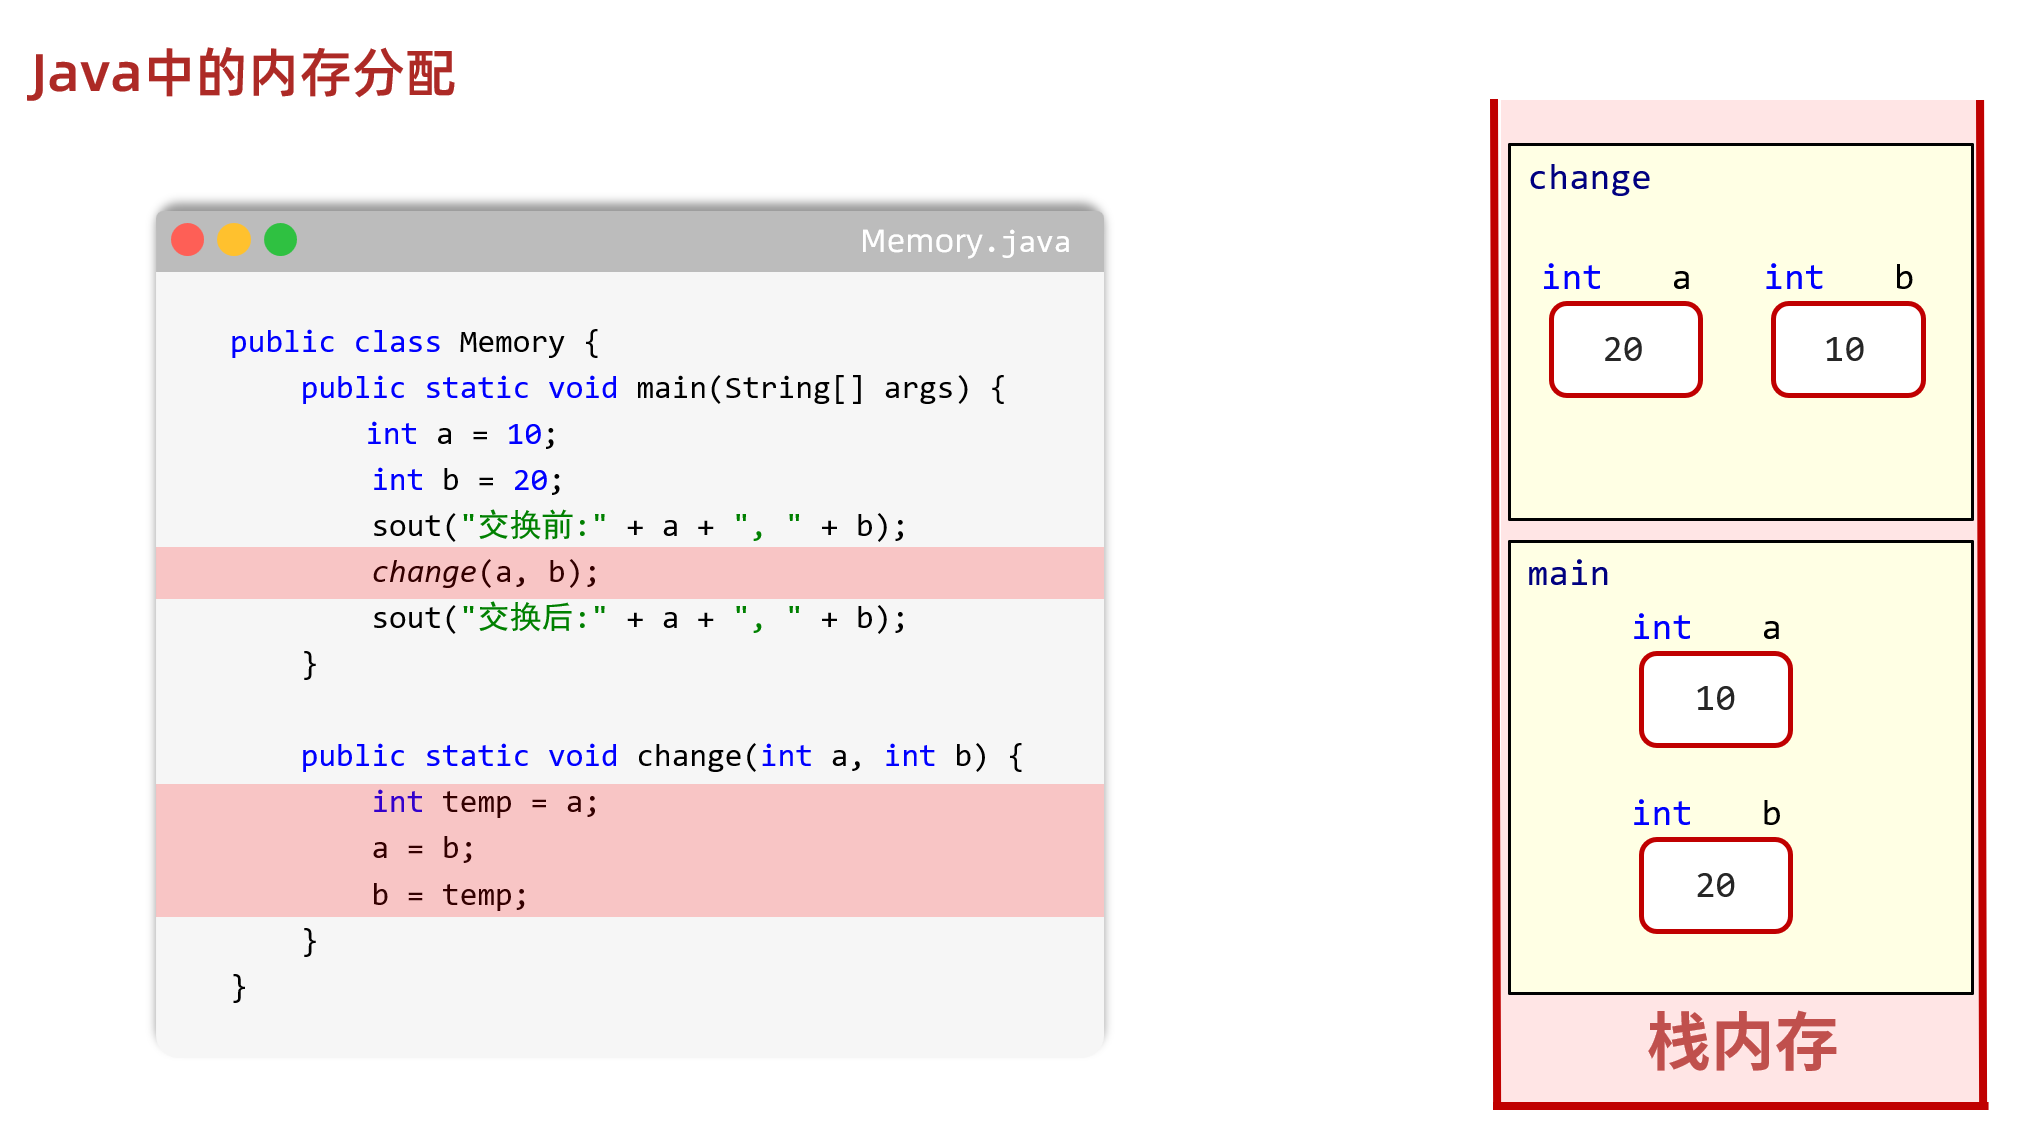

1. change方法里面所有的代码执行完毕之后，就会从栈里面出去，方法里面的变量也会随之消失。

内存图解如下：

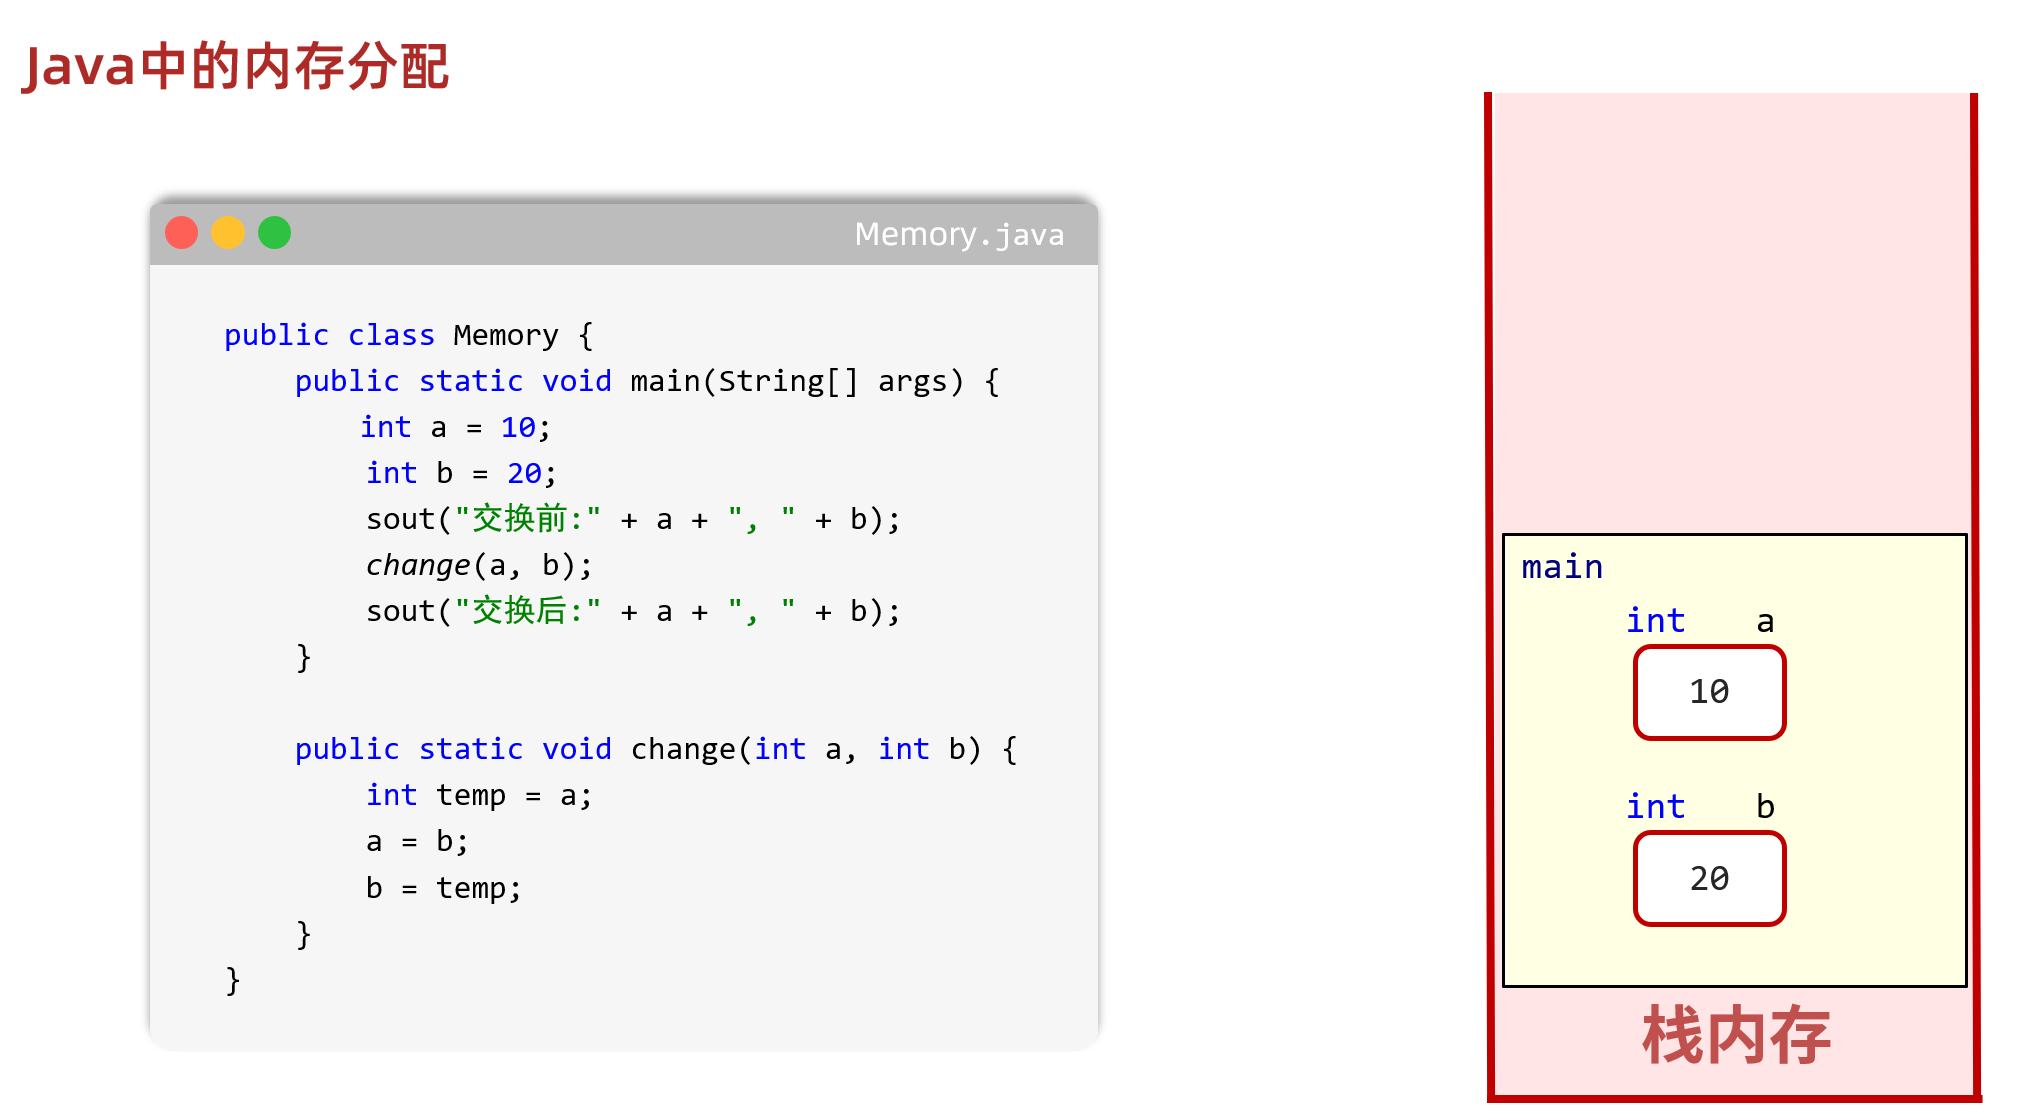

1. 继续执行main方法里面的，再次打印a和b，最终结果就是10和20。这就是基本数据类型在方法中进行传递的完整过程。

> 基本数据类型，变量里面记录的是真实的数据，传递也是真实的数据。两个变量ab，变量a把真实的数据给b了，b想怎么改，就怎么改，不会影响到a里面记录的值。


## 数组在内存中的情况

接下来，我们学习数组在内存中的情况，代码如下：

````java
public class Memory {
    public static void main(String[] args) {
       int[] arr = {1, 2, 3};
    }
}
````

<strong>完整流程如下：</strong>

1. 把相关类的字节码文件，加载到方法区。此时<code>Memory.class</code>就在内存中了
2. 虚拟机自动调用main方法，main方法，被加载进栈，准备从上往下依次执行代码。
3. 创建数组的这行代码，左右两部分在不同的内存中。
4. 等号的左边：arr其实就是一个变量，是在栈里面的。数据类型int&#91;&#93;，表示能存int类型数组的地址值
5. 等号的右边：完整的格式中有new，所以是在堆里面开辟一个小空间。
6. 又因为，数组的长度是3，所以，又把new出来的空间，划分了3个小格子，每一个格子都有自己的索引，并存储数据：1，2，3
7. 通过中间的等号（赋值运算符），把右边数组的地址值，赋值给左边的变量arr，这样通过arr记录的内存地址就可以找到右边的数组了。

以上这就是数组在内存中完整的结构。内存图解如下：

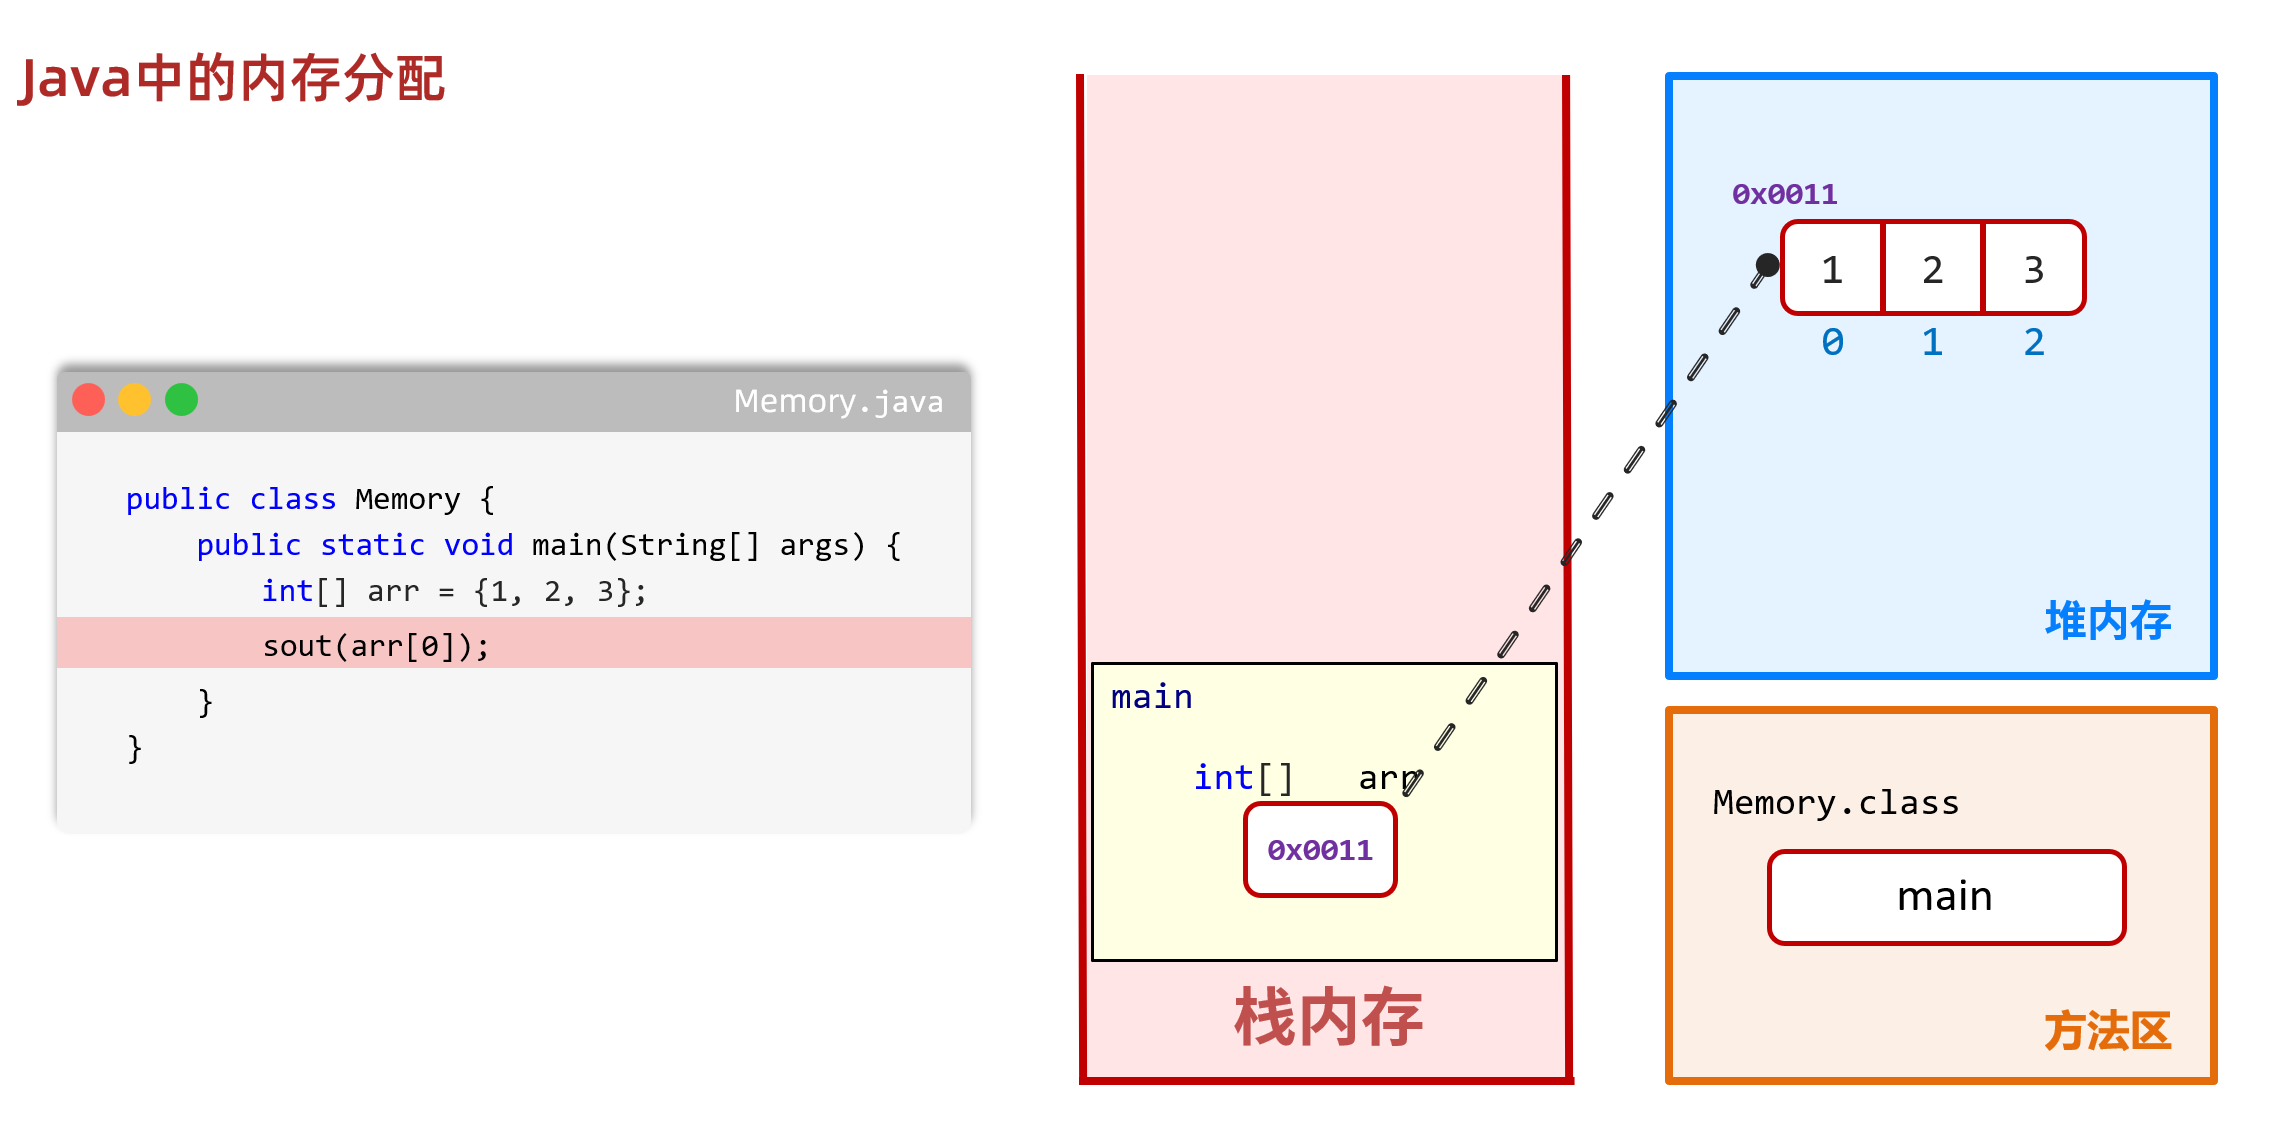


## 访问数组的元素

如果我想获取数组中的元素、修改数组中的元素在内存中是怎么进行的呢？我们一起来学习一下，代码如下：

````java
public class Memory {
    public static void main(String[] args) {
       int[] arr = {1, 2, 3};
       System.out.println(arr[0]);
       arr[1] = 100;
       System.out.println(arr);
    }
}
````

<strong>获取完整流程如下：</strong>

1. 先找arr记录的内存地址
2. 通过内存地址，找堆里面的数组，再获取其中的0索引，得到数据1

<strong>修改完整流程如下：</strong>

1. 先找arr记录的内存地址
2. 通过内存地址，找堆里面的数组，再获取其中的1索引，进行修改，原来的数据就被覆盖了。

<strong>注意：</strong>

直接打印arr，会打印里面的数据吗？

答案是不会的。

arr里面记录的是什么，他就打印什么。所以此时，打印的是内存地址，比如：<code>&#91;I@0011</code>

这个地址Java做了一些优化：

> **勘误：**直接打印数组得到的形式类似 `[I@1b6d3586`，它来自 `Object.toString()`：`[I` 表示 `int[]` 的类描述符，`@` 后面通常是对象身份哈希值的十六进制表示，不是可以拿来寻址的真实内存地址。要打印元素可使用 `Arrays.toString(arr)`，并导入 `java.util.Arrays`。

第一部分：前面的方括号，表示现在打印的内存地址，是一个数组的

第二部分：I是数组的类型，是int整数类型的，如果是小数类型的数组，这里就是大写的D

第三部分：@是固定格式，间隔符

第四部分：@后面的一串数字，就是十六进制表示的内存地址，只不过，每一个人打印的内存地址有可能是不一样的，因为new关键字在堆里面开辟的空间不是固定的。


## 数组在方法中进行传递

数组在方法当中进行传递跟变量在方法当中进行传递是完整不一样的，接下来我们来学习一下，代码如下：

> **补充：**Java 始终按值传递参数。基本类型传递的是基本值的副本；数组参数传递的是“引用值”的副本。调用方和方法内的两个引用仍指向同一个数组，所以修改 `arr[0]` 会被调用方看到；若在方法内让形参 `arr` 指向新数组，则不会改变调用方变量本身。

````java
public class Memory {
    public static void main(String[] args) {
       int[] arr = {1, 2, 3};
        System.out.println("交换前:"arr[0]+arr[1]+arr[2]);
        change(arr);
        System.out.println("交换后:"+arr[0]+arr[1]+arr[2]);
 }
    public static void change(int[] arr) {
        int temp = arr[0];
        arr[0] = arr[2];
        arr[2] = temp;
    }
````

> **勘误：**这行少了字符串和第一个元素之间的 `+`，应写为 `System.out.println("交换前:" + arr[0] + "," + arr[1] + "," + arr[2]);`。讲义代码片段还缺少类结尾的大括号，整理成完整类后才能编译。

<strong>完整流程如下：</strong>

1. 把相关类的字节码文件，加载到方法区。此时<code>Memory.class</code>就在内存中了
2. 虚拟机自动调用main方法，main方法，被加载进栈，准备从上往下依次执行代码。
3. 创建数组等号的左边：在栈里面定义一个叫做arr的变量，用于存储数组的地址值。
4. 等号的右边：堆里面开辟一个小空间，存储数组的数据。
5. 把右边数组的地址值，赋值给左边的变量arr

内存图解如下：

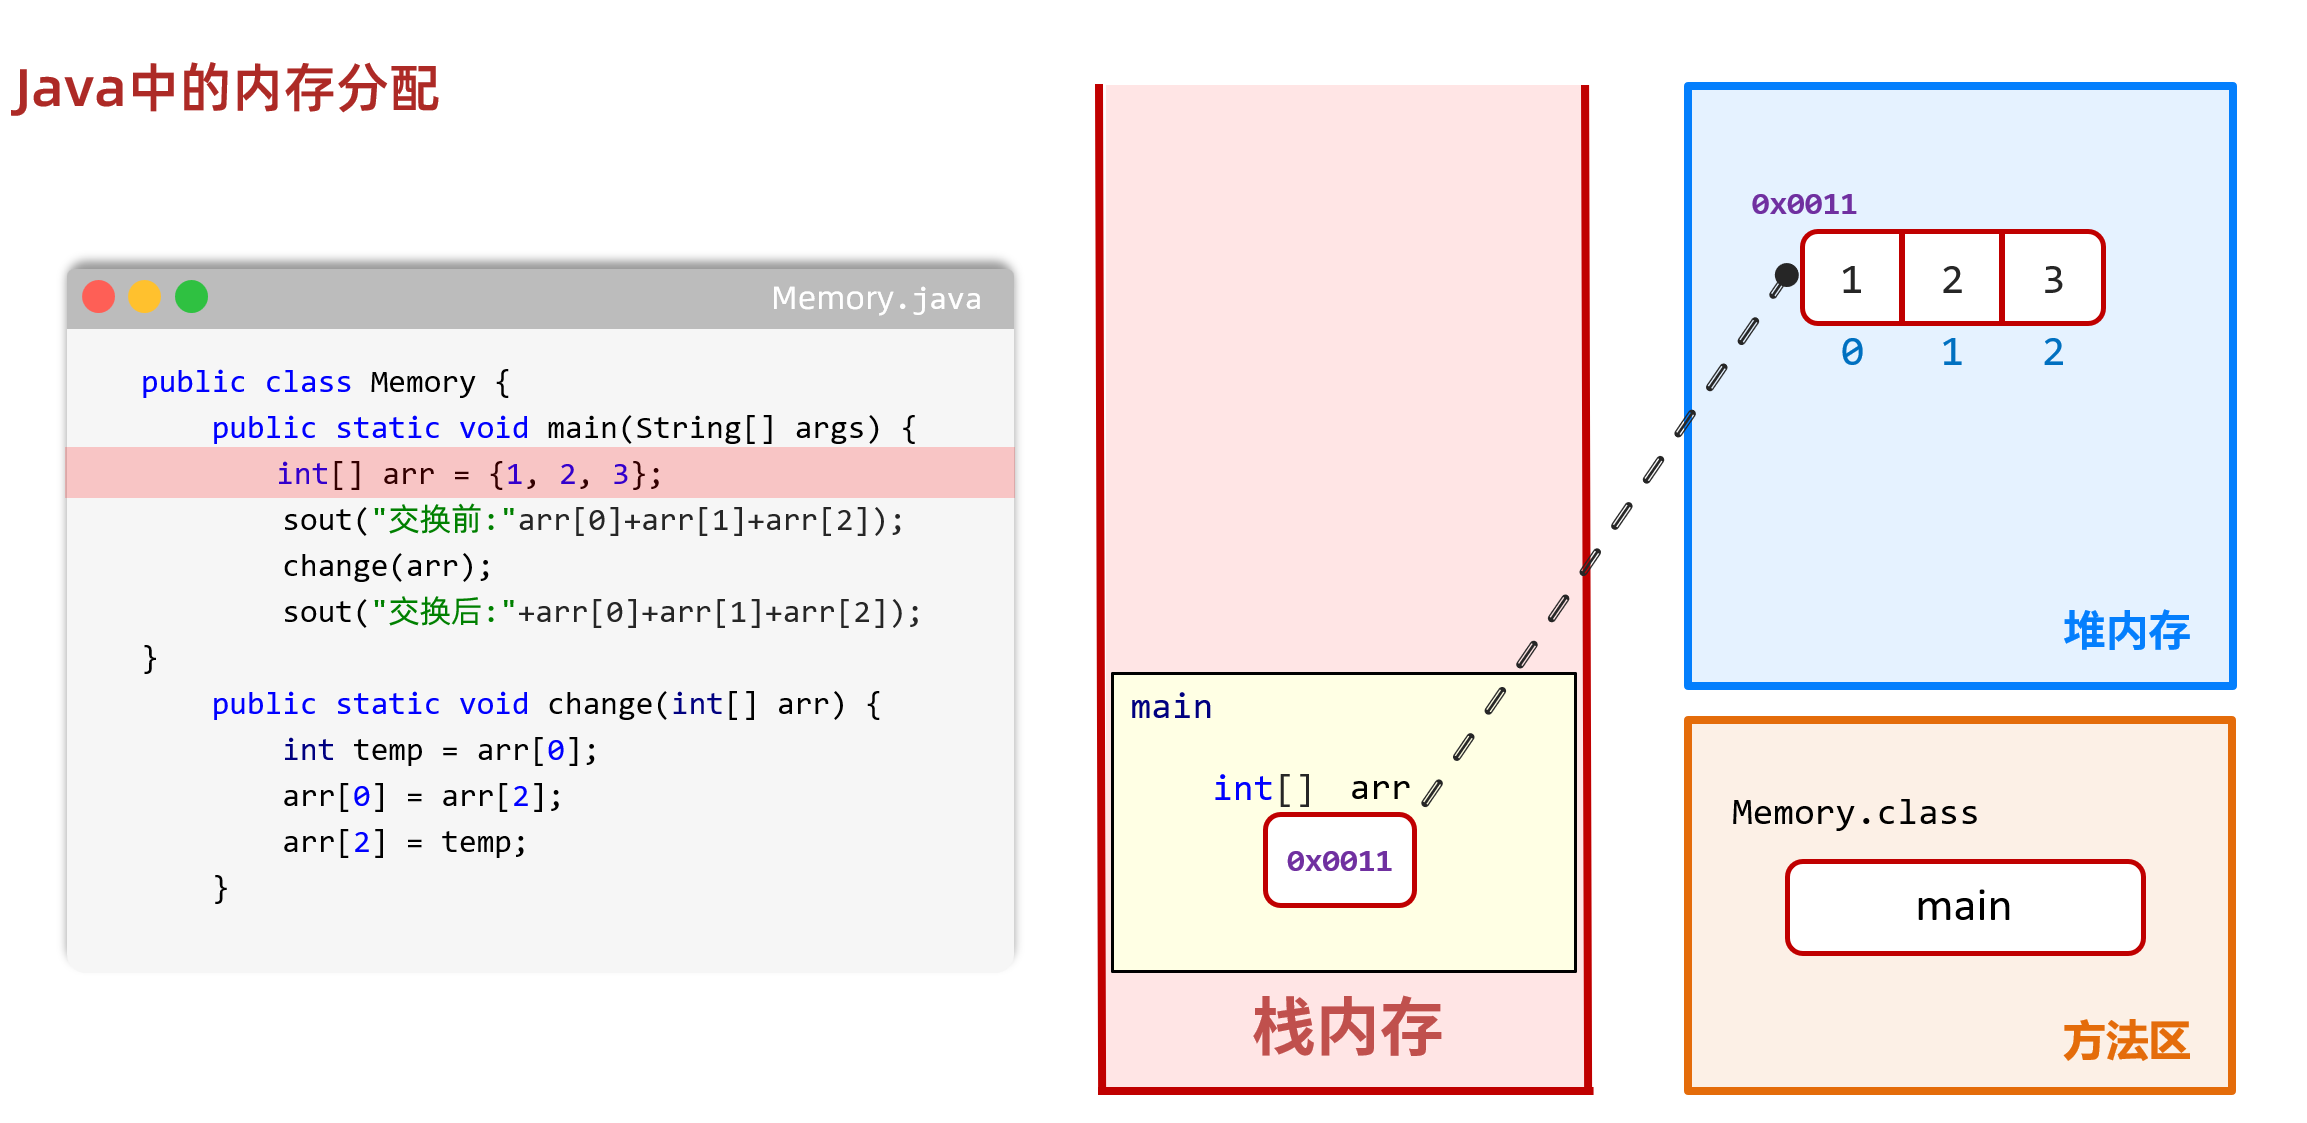

1. 通过arr依次获取0索引，1索引，2索引。打印数据：1，2，3。
2. 调用了change方法，方法被调用，进栈执行。change方法里面有一个形参，也叫做arr，也记录地址0x0011。通过0x0011地址值，也能找到右边的数组。

> **补充：**`0x0011` 只是图解中的假地址。Java 变量保存的是由 JVM 管理的引用值，垃圾回收可能移动对象，Java 代码不能把这个引用当作可运算的 C/C++ 裸指针。

> <strong>备注：</strong>在调用方法的时候，实际参数如果是变量，变量记录什么就传递什么。

内存图解如下：

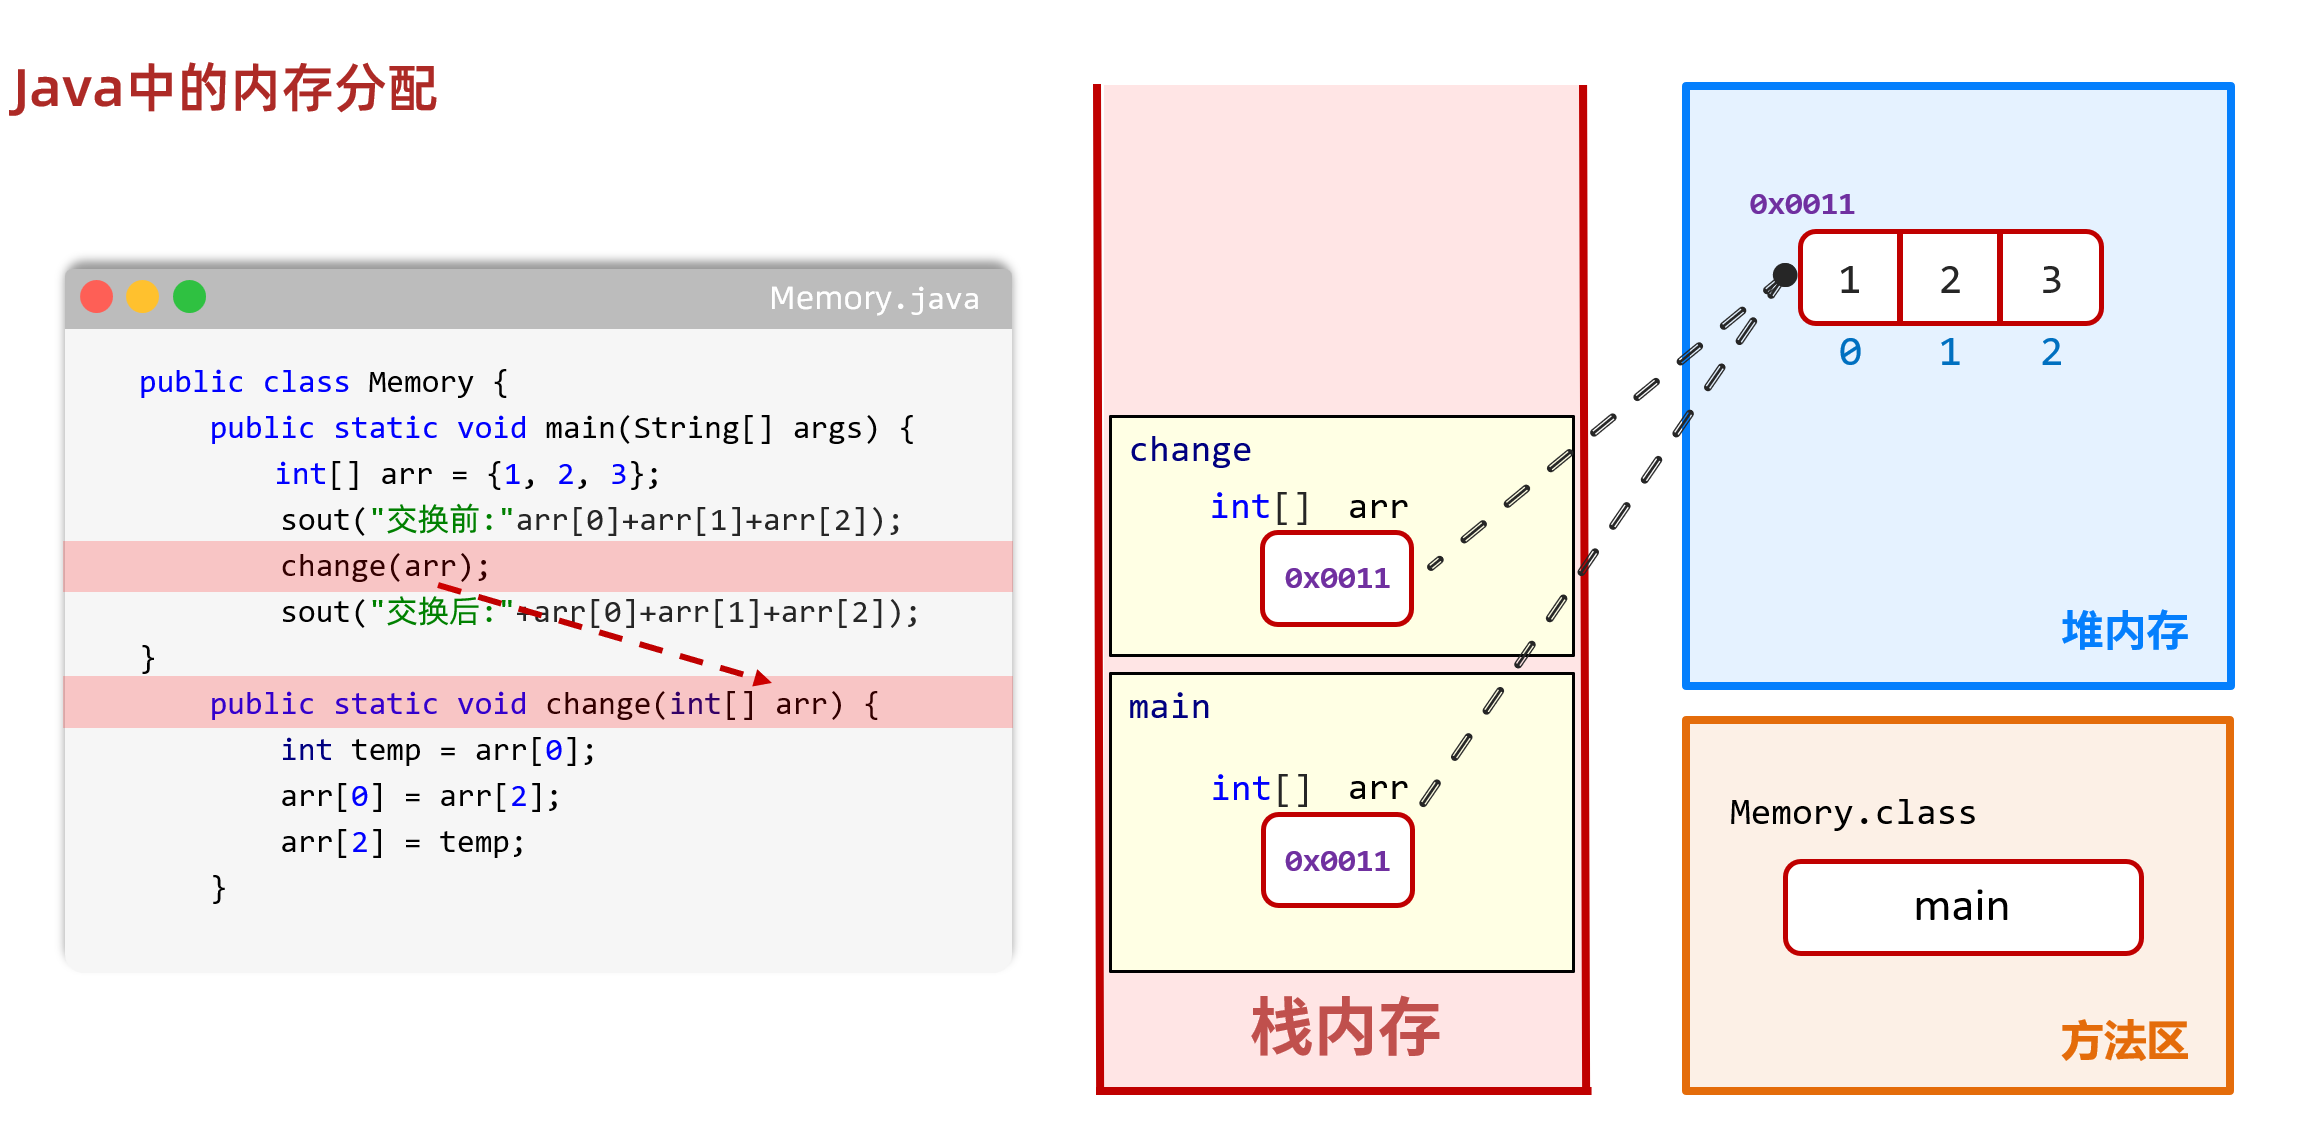

1. 执行change里面的代码，交换首尾元素。

内存图解如下：

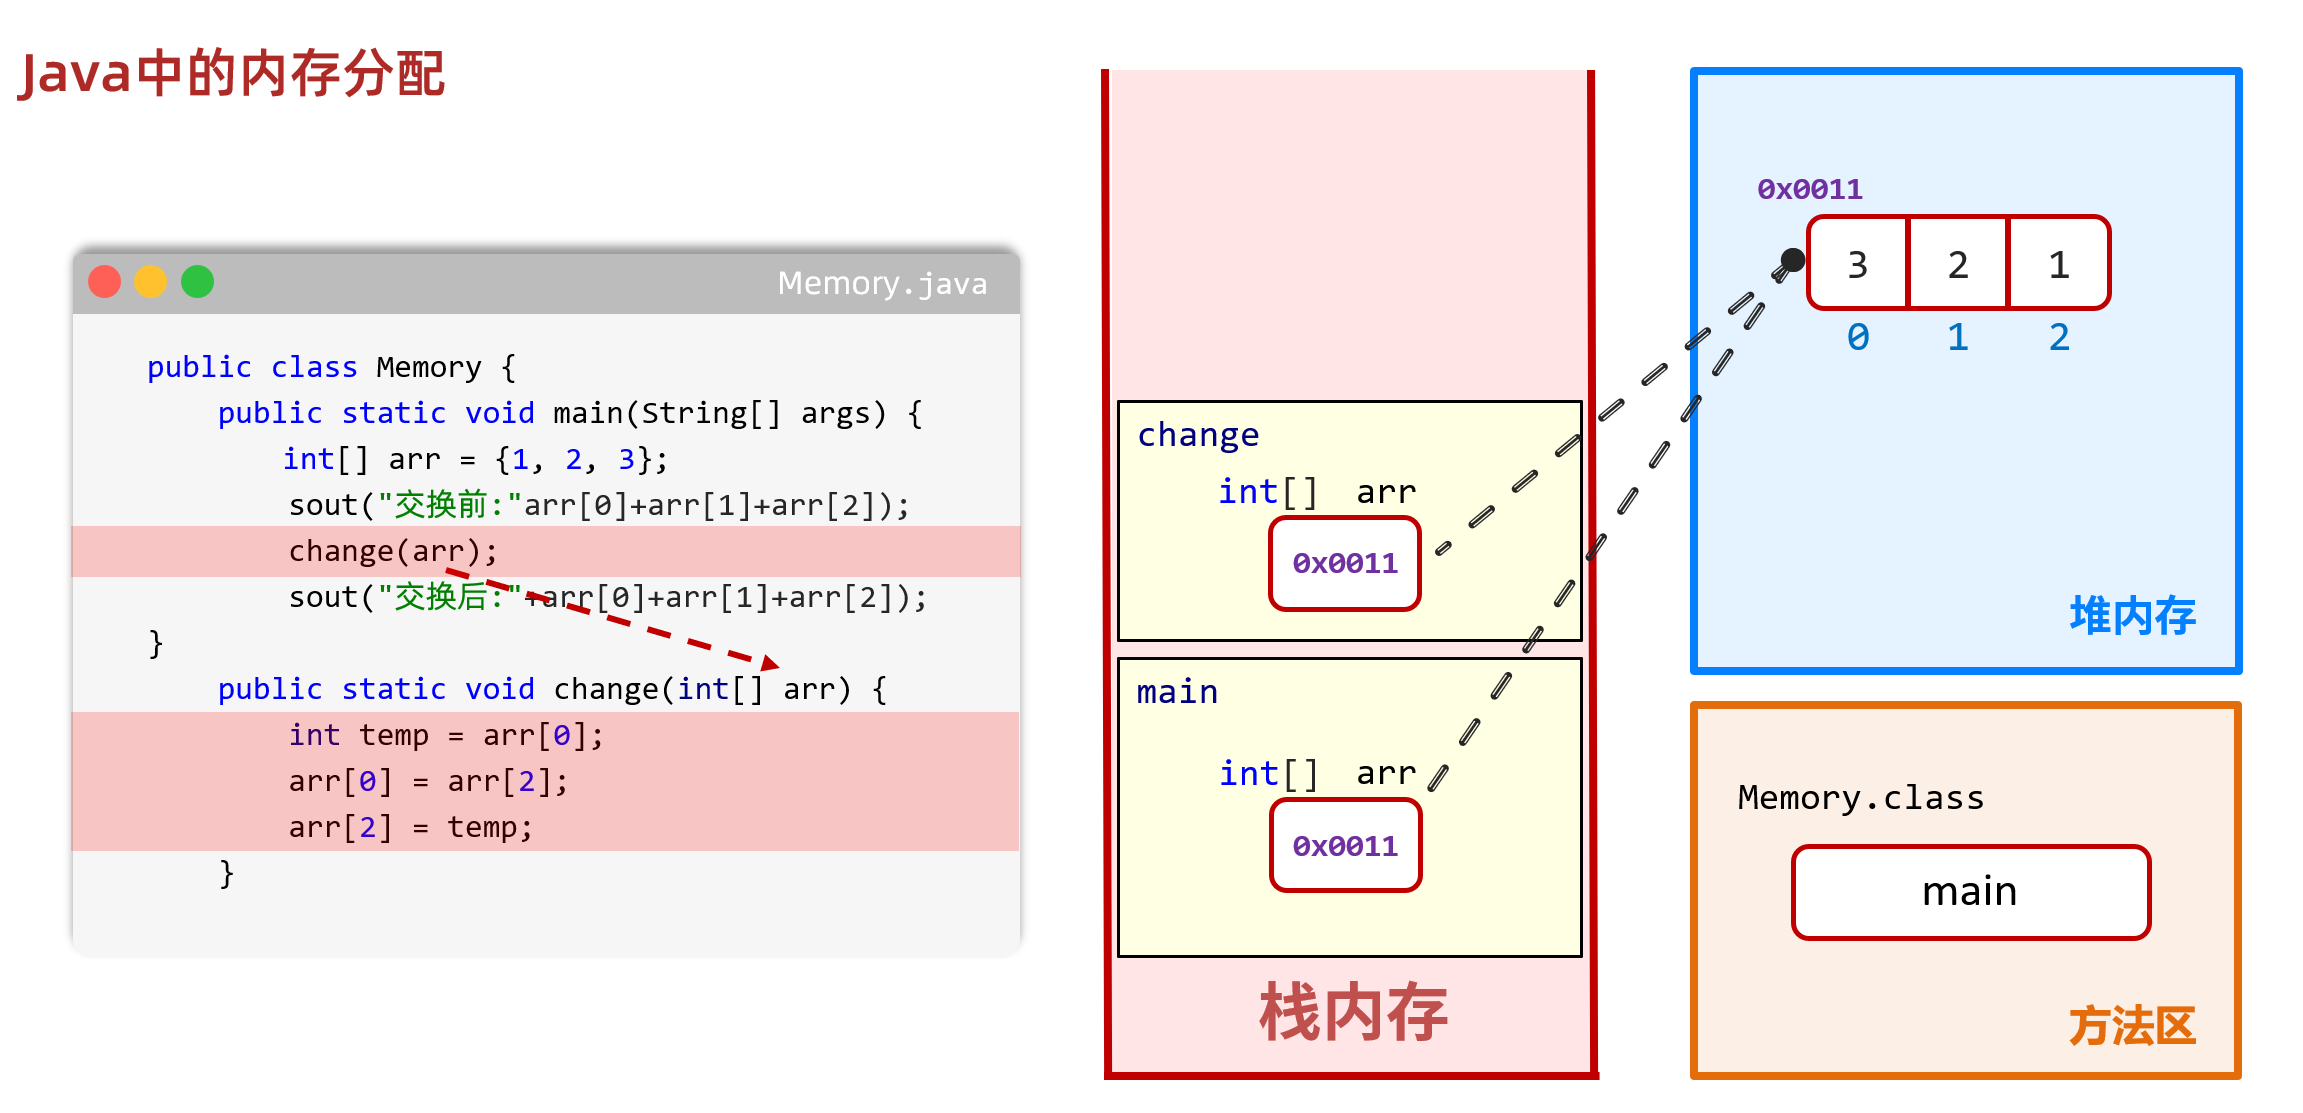

1. 交换完毕，change方法所有代码执行完毕，从栈里面出去。方法出栈了，方法里面的变量，也从内存中消失了。

2. 继续执行main方法下面的代码，通过arr，再去访问元素就是修改之后的结果了。

    最终打印：3,2,1
